# 신경망 언어 모델(NNLM)

**신경망 언어 모델(NNLM, Neural Network Language Model)** 은 앞의 토큰 문맥을 신경망 입력으로 받아 다음 토큰의 로짓을 계산하는 모델이다. 이 노트북에서는 문맥 길이를 두 토큰으로 고정한 feed-forward NNLM을 사용한다.

## 계산 구조

두 문맥 토큰은 다음 순서로 어휘 전체의 다음 토큰 점수로 변환된다.

```text
토큰 ID → Embedding → Flatten → hidden + tanh → logits
```

- **Embedding**: 각 토큰 ID로 학습 가능한 임베딩 행을 조회한다.
- **Flatten**: 두 토큰 벡터를 순서대로 이어 붙여 하나의 고정 길이 문맥 벡터를 만든다.
- **hidden**: 선형 변환과 `tanh`로 문맥의 비선형 특징을 만든다.
- **logits**: 출력층이 어휘의 모든 다음 토큰 후보 점수를 계산한다.

## N-gram과 다른 특징

N-gram이 완전히 같은 문자열 조합의 빈도를 저장한다면 NNLM은 임베딩과 계층 가중치를 학습한다. `CrossEntropyLoss`를 역전파하면 입력 토큰이 조회한 임베딩 행부터 은닉층과 출력층까지 함께 갱신되므로, 토큰을 단순한 기호가 아니라 연속적인 벡터 특징으로 표현한다.

## 장점과 한계

임베딩과 신경망 가중치로 문맥 특징을 학습할 수 있고 전체 계산 경로를 작은 코드로 추적하기 쉽다는 장점이 있다. 반면 RNN처럼 상태를 순차적으로 전달하지 않으며 입력 문맥 길이가 고정되어 범위 밖의 장기 의존성을 기억하지 못하고, 문맥을 늘릴수록 입력 차원도 커진다.

## 대표 사용처

feed-forward NNLM은 임베딩 학습 원리를 설명하는 기초 모델이며, 짧은 문맥의 자동완성이나 후보 재순위화에 사용할 수 있다. 현대 생성 모델의 주 구조는 아니지만 N-gram에서 RNN·Transformer로 넘어가는 학습 연결을 이해하는 데 유용하다.

## 이번 노트북에서 확인할 내용

작은 한국어 코퍼스에서 모델이 실제로 학습되고 예측에 사용되는 전체 경로를 확인한다.

- 두 토큰 문맥과 다음 토큰 정답 ID를 만드는 방법
- 계층별 shape와 임베딩 값의 학습 전후 변화
- loss·perplexity·top-k 확률의 변화
- 학습한 확률을 반복 사용하는 greedy 자동회귀 생성

먼저 그림으로 학습 전체 경로를 연결한 뒤, 같은 순서를 데이터 준비·모델 정의·초기 예측·역전파·생성 코드에서 단계별로 확인한다.


## 01. NNLM의 입력부터 학습까지

문맥 토큰 두 개는 각각 8차원 임베딩으로 바뀐다. 모델의 forward 경로에서는 다음 shape 변화가 일어난다.

- 문맥 ID `(B, 2)`가 임베딩 `(B, 2, 8)`로 바뀐다.
- 두 임베딩을 평균 내지 않고 이어 붙여 `(B, 16)`을 만든다.
- 은닉층이 `(B, 32)` 문맥 특징을 만들고 출력층이 어휘 로짓 `(B, V)`를 계산한다.

정답 다음 토큰과 로짓을 `CrossEntropyLoss`로 비교하고 역전파하면, 임베딩·은닉층·출력층의 가중치가 함께 수정된다. 학습 전 임베딩은 무작위 값이지만 오차를 줄이는 방향으로 반복 수정되면서 현재 코퍼스의 문맥 패턴을 담게 된다.

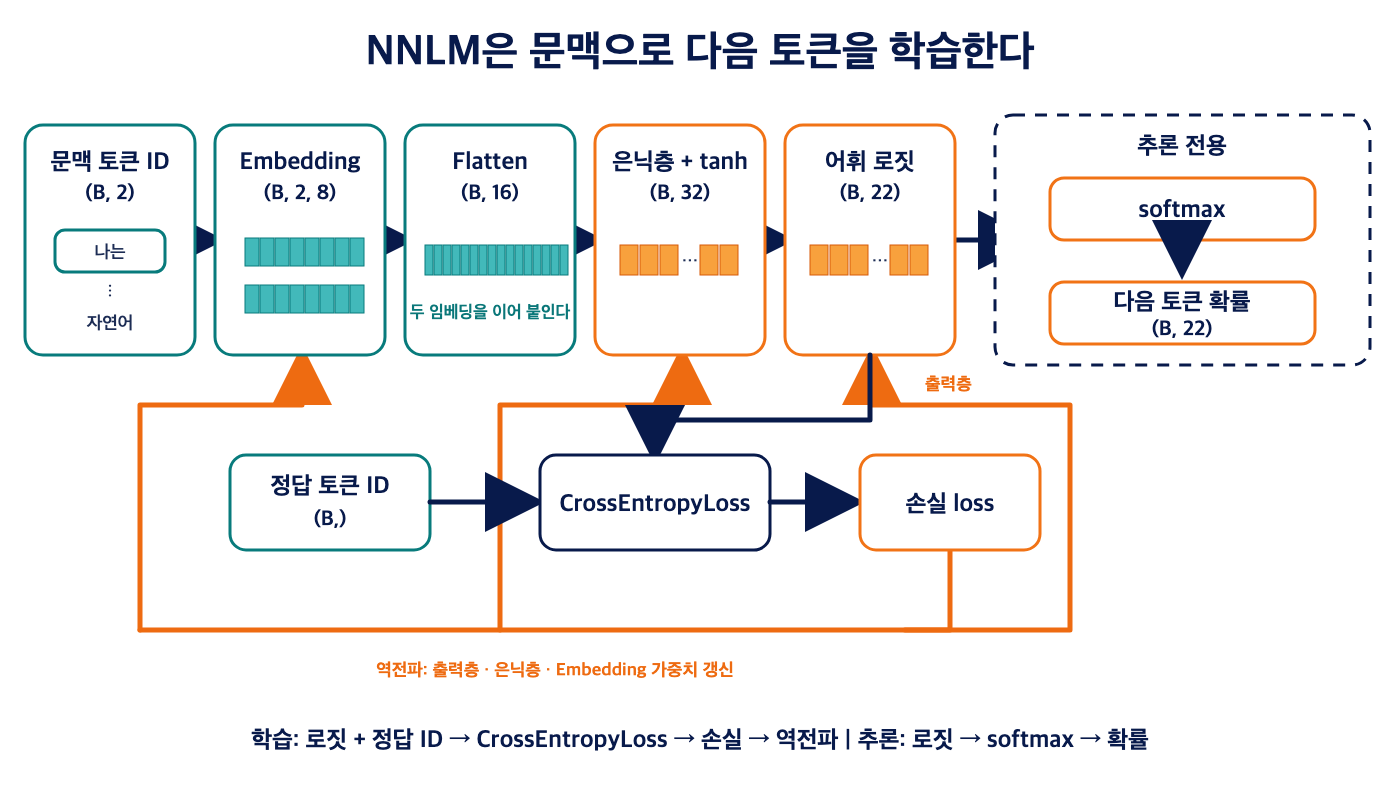

그림에서 `B`는 한 번에 처리하는 문맥-정답 쌍의 개수이고 `V`는 어휘 크기이다. `(B, 2, 8) → (B, 16)`에서 두 토큰의 순서는 서로 다른 구간에 보존되므로 첫 토큰과 둘째 토큰을 구분할 수 있다.

어휘 로짓 뒤의 경로는 용도에 따라 갈라진다. 학습에서는 로짓과 정답 ID를 `CrossEntropyLoss`에 직접 넣고, 추론에서 top-k를 구할 때만 `softmax`로 확률을 만든다. 역전파 화살표는 손실의 기울기가 출력층·은닉층·임베딩 가중치까지 전달된다는 뜻이다. 다음 절에서는 이 그림에 들어갈 `(문맥, 정답)` 쌍을 실제 문장에서 만든다.


## 02. 문맥-정답 학습 데이터 만들기

문맥 길이가 `2`이면 각 정답 바로 앞의 토큰 두 개가 입력이 된다. 문장 앞에서도 두 토큰을 확보하기 위해 `<s>`를 두 번 붙이고, 문장 종료 자체도 예측하도록 `</s>`를 정답에 포함한다.

특수 토큰은 문장 가장자리와 미등록 문자열도 유효한 ID로 처리하기 위해 사용한다.

- `<s>`: 문장 시작 전에 실제 단어가 아직 없다는 것을 표시하는 입력 토큰이다.
- `</s>`: 모델이 문장 종료도 다음 토큰 정답으로 학습하게 한다.
- `<OOV>`: 학습 어휘에 없는 새 문자열을 하나의 ID로 바꾸어 유효한 Embedding 행을 조회하게 한다.

`<OOV>`가 원래 단어의 뜻을 보존하는 것은 아니므로 실제 시스템에서는 서브워드 토큰화로 미등록 단어 문제를 줄인다.

```text
원문: 나는 자연어 처리를 공부한다

[<s>, <s>]      → 나는
[<s>, 나는]     → 자연어
[나는, 자연어]  → 처리를
[자연어, 처리를] → 공부한다
[처리를, 공부한다] → </s>
```

한 문장에 여러 학습 쌍이 만들어지며, 모든 쌍을 모델에 한 번 전달하는 것을 한 epoch로 본다. 이어지는 코드 출력에서 첫 다섯 쌍과 `context_ids (B, 2)`, `target_ids (B,)`를 함께 확인하면 문자열 문장이 모델 입력과 손실 정답으로 분리된 과정을 추적할 수 있다.


In [1]:
import math
import random

import numpy as np
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sentences = [
    ["나는", "자연어", "처리를", "공부한다"],
    ["나는", "자연어", "처리를", "배운다"],
    ["나는", "자연어", "처리를", "좋아한다"],
    ["나는", "언어", "모델을", "공부한다"],
    ["나는", "언어", "모델을", "배운다"],
    ["나는", "머신러닝", "모델을", "공부한다"],
    ["학생은", "자연어", "처리를", "공부한다"],
    ["학생은", "언어", "모델을", "배운다"],
    ["언어", "모델은", "다음", "단어를", "예측한다"],
    ["자연어", "처리는", "문장을", "분석한다"],
    ["머신러닝", "모델은", "데이터를", "학습한다"],
]

START_TOKEN = "<s>"
END_TOKEN = "</s>"
OOV_TOKEN = "<OOV>"
CONTEXT_SIZE = 2

corpus_tokens = sorted({token for sentence in sentences for token in sentence})
index_to_word = [START_TOKEN, END_TOKEN, OOV_TOKEN, *corpus_tokens]

# 사전
word_to_index = {
    word: index
    for index, word in enumerate(index_to_word)
}

training_examples = []
for sentence in sentences:
    padded_sentence = [START_TOKEN] * CONTEXT_SIZE + sentence + [END_TOKEN]

    for target_position in range(CONTEXT_SIZE, len(padded_sentence)):
        context_tokens = padded_sentence[
            target_position - CONTEXT_SIZE:target_position
        ]
        target_token = padded_sentence[target_position]
        training_examples.append((context_tokens, target_token))

context_id_rows = [
    [word_to_index[token] for token in context_tokens]
    for context_tokens, _ in training_examples
]
target_id_values = [
    word_to_index[target_token]
    for _, target_token in training_examples
]

context_ids = torch.tensor(context_id_rows, dtype=torch.long)
target_ids = torch.tensor(target_id_values, dtype=torch.long)

print("어휘 크기:", len(index_to_word))
print("학습 쌍 수:", len(training_examples))
print("문맥 ID shape:", tuple(context_ids.shape))
print("정답 ID shape:", tuple(target_ids.shape))
print("첫 다섯 학습 쌍:")
for context_tokens, target_token in training_examples[:5]:
    print(f"  {context_tokens} → {target_token}")


어휘 크기: 22
학습 쌍 수: 56
문맥 ID shape: (56, 2)
정답 ID shape: (56,)
첫 다섯 학습 쌍:
  ['<s>', '<s>'] → 나는
  ['<s>', '나는'] → 자연어
  ['나는', '자연어'] → 처리를
  ['자연어', '처리를'] → 공부한다
  ['처리를', '공부한다'] → </s>


## 03. Feed-forward NNLM 정의와 shape

`nn.Embedding`의 가중치 shape은 `(어휘 크기, 임베딩 차원)`이다. 토큰 ID는 해당 행을 선택하며, 학습 과정에서 그 행의 값도 다른 계층 가중치와 함께 수정된다. 여기서 `weight`는 빈도나 중요도가 아니라 optimizer가 갱신할 실수 행렬이다.

`Flatten`은 두 토큰 임베딩을 이어 붙인다. 이후 `tanh` 은닉층이 문맥 특징을 만들고 마지막 선형 계층이 어휘 크기만큼 로짓을 출력한다. 모델 내부에 `softmax`를 넣지 않는 이유는 `CrossEntropyLoss`가 로짓을 직접 받아 안정적으로 확률 계산과 손실 계산을 함께 처리하기 때문이다.

코드는 `자연어`의 토큰 ID `16`이 선택하는 임베딩 행을 학습 전에 복사한다. 이 행의 8개 실수는 단어의 확률이나 토큰 ID가 아니라 optimizer가 바꾸는 학습 파라미터이다.

출력에서는 다음 연결을 확인한다.

- 입력 `(56, 2)`가 로짓 `(56, 22)`로 변환되는지 확인한다.
- 임베딩 가중치 shape `(22, 8)`의 첫 축이 어휘 ID와 대응하는지 확인한다.
- 학습 전 `자연어` 임베딩 복사본이 뒤의 학습 후 비교 기준으로 보존되는지 확인한다.


In [2]:
# 두 토큰 임베딩을 펼쳐 은닉 특징과 어휘 전체 로짓으로 전달한다.
class FeedForwardNNLM(nn.Module):
    """두 토큰 문맥으로 다음 토큰 로짓을 계산하는 신경망이다."""

    def __init__(
        self,
        vocabulary_size,
        context_size,
        embedding_dim=8,
        hidden_dim=32,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocabulary_size, embedding_dim)

        self.hidden = nn.Linear(context_size * embedding_dim, hidden_dim)

        self.output = nn.Linear(hidden_dim, vocabulary_size)

    def forward(self, token_ids):
        # 임베딩 (배치 11, 문맥 길이 2, 벡터 차원 8)
        embedded = self.embedding(token_ids)
        # (배치, 벡터 차원) -> 평탄화
        flattened = embedded.reshape(embedded.size(0), -1)
        # 은닉 계층에서 16 -> 32 차원으로 변경 -> tanh으로 비선형 문맥 특징 생성
        hidden_features = torch.tanh(self.hidden(flattened))
        # 어휘 사전 단어 수만큼으로 logit 반환
        logits = self.output(hidden_features)
        return logits

model = FeedForwardNNLM(
    vocabulary_size=len(index_to_word),  # 22 in -> 22 logit 출력
    context_size=CONTEXT_SIZE, # 문맥 길이 2
    embedding_dim=8,
    hidden_dim=32,
)

# 학습 전 기록
tracked_token = "자연어"
tracked_token_id = word_to_index[tracked_token]
initial_embedding_vector = (
    model.embedding.weight[tracked_token_id]
    .detach()
    .clone()
)

with torch.no_grad():
    shape_check_logits = model(context_ids)

print("입력 shape:", tuple(context_ids.shape))
print("출력 로짓 shape:", tuple(shape_check_logits.shape))
print("임베딩 가중치 shape:", tuple(model.embedding.weight.shape))
print(f"추적 토큰과 ID: {tracked_token!r}, {tracked_token_id}")
print(
    "초기 임베딩 앞 4개 값:",
    [round(value, 4) for value in initial_embedding_vector[:4].tolist()],
)


입력 shape: (56, 2)
출력 로짓 shape: (56, 22)
임베딩 가중치 shape: (22, 8)
추적 토큰과 ID: '자연어', 16
초기 임베딩 앞 4개 값: [1.9312, 1.0119, -1.4364, -1.1299]


## 04. 학습 전 다음 토큰 확률

학습 전에도 forward와 softmax를 실행하면 로짓과 확률을 출력할 수 있다. 그러나 이 값은 무작위 초기 가중치에서 나온 기준값일 뿐 언어 패턴을 반영하지 않는다.

`[<s>, 나는]` 문맥은 코퍼스에서 `자연어`, `언어`, `머신러닝`으로 이어진다. 코드에서는 문자열 문맥을 ID `(1, 2)`로 바꾸고, 로짓 `(1, V)`를 확률로 변환한 뒤 top-k의 ID를 다시 토큰 문자열로 복원한다.

학습 전 top-k와 `자연어`의 개별 확률을 Python 값으로 저장해 두면 optimizer가 가중치를 바꾼 뒤에도 같은 문맥의 초기 분포와 직접 비교할 수 있다. 현재 순위가 코퍼스 빈도와 다르더라도 학습 전 기준에서는 정상이다.


In [3]:
# 같은 문맥의 top-k와 목표 토큰 확률을 학습 전 기준으로 저장한다.
def top_k_next_tokens(model, context_tokens, k=5):
    """문맥 다음에 올 확률이 높은 토큰과 확률을 반환한다."""
    model.eval()

    context_token_ids = [
        word_to_index.get(token, word_to_index[OOV_TOKEN])
        for token in context_tokens
    ]

    input_tensor = torch.tensor([context_token_ids], dtype=torch.long)

    with torch.no_grad():
        logits = model(input_tensor)

        probabilities = torch.softmax(logits, dim=-1)

        top_probabilities, top_ids = torch.topk(
            probabilities,
            k=k,
            dim=-1,
        )

    ranked_tokens = []
    for token_id, probability in zip(
        top_ids[0].tolist(),
        top_probabilities[0].tolist(),
    ):
        ranked_tokens.append((index_to_word[token_id], probability))
    return ranked_tokens

def next_token_probability(model, context_tokens, target_token):
    """지정한 문맥에서 목표 토큰 하나에 할당된 확률을 반환한다."""
    context_token_ids = [
        word_to_index.get(token, word_to_index[OOV_TOKEN])
        for token in context_tokens
    ]
    context_tensor = torch.tensor([context_token_ids], dtype=torch.long)
    target_token_id = word_to_index[target_token]

    with torch.no_grad():
        logits = model(context_tensor)
        probabilities = torch.softmax(logits, dim=-1)

    return float(probabilities[0, target_token_id])

inspection_context = [START_TOKEN, "나는"]
inspection_target = "자연어"

initial_top_k = top_k_next_tokens(model, inspection_context, k=5)
initial_target_probability = next_token_probability(
    model,
    inspection_context,
    inspection_target,
)

print("학습 전 문맥:", inspection_context)
for rank, (token, probability) in enumerate(initial_top_k, start=1):
    print(f"  {rank}. {token:<8} 확률={probability:.4f}")
print(f"목표 토큰 {inspection_target!r} 확률: {initial_target_probability:.4f}")


학습 전 문맥: ['<s>', '나는']
  1. 모델은      확률=0.0743
  2. 다음       확률=0.0708
  3. 데이터를     확률=0.0660
  4. 머신러닝     확률=0.0620
  5. 배운다      확률=0.0562
목표 토큰 '자연어' 확률: 0.0296


## 05. 다음 토큰 학습

`CrossEntropyLoss`는 각 문맥의 `(V,)` 로짓과 정답 토큰 ID 하나를 비교한다. 전체 배치 학습에서는 다음 네 단계가 한 epoch마다 반복된다.

- `optimizer.zero_grad()`로 이전 기울기를 지운다.
- forward로 `(56, 22)` 로짓을 만들고 정답 ID와 평균 loss를 계산한다.
- `loss.backward()`로 출력층부터 임베딩까지 기울기를 전파한다.
- `optimizer.step()`으로 임베딩·은닉층·출력층 가중치를 갱신한다.

Perplexity는 평균 cross-entropy loss를 지수화한 `exp(loss)`이며, 현재 모델이 정답을 고를 때 평균적으로 몇 개 후보 사이에서 헷갈리는지 해석하는 지표이다. 같은 데이터와 토큰화 조건에서는 낮을수록 정답에 더 높은 확률을 준 것이지만, 여기서 계산하는 값은 학습 코퍼스 자체의 지표이다.

이 실습은 데이터 흐름을 확인하기 위한 작은 코퍼스를 전체 배치로 반복 학습한다. loss와 perplexity가 감소하면 학습 문맥의 실제 정답에 부여한 확률이 높아지고 있다는 뜻이지만, 새로운 도메인의 일반화 성능을 입증하지 않는다.

학습 뒤에는 `자연어` 임베딩의 같은 네 위치를 다시 출력하고, 초기 벡터와 학습 벡터 차이의 L2 norm도 계산한다. 출력에서는 loss·perplexity 감소와 0보다 큰 임베딩 변화량을 함께 본다. 단순히 shape가 같다는 사실이 아니라 임베딩 행의 실제 숫자까지 optimizer 갱신으로 달라졌다는 증거가 필요하다.


In [4]:
# CrossEntropyLoss를 역전파해 임베딩부터 출력층까지 함께 학습한다.
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.03)

EPOCHS = 300
loss_history = []

model.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    logits = model(context_ids)

    loss = criterion(logits, target_ids)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch == 1 or epoch % 50 == 0:
        perplexity = math.exp(loss.item())
        print(
            f"epoch={epoch:>3} "
            f"loss={loss.item():.4f} "
            f"perplexity={perplexity:.3f}"
        )

# 최적화를 모두 마친 뒤 같은 토큰으로 초기 임베딩과 비교
trained_embedding_vector = (
    model.embedding.weight[tracked_token_id]
    .detach()
    .clone()
)

embedding_change = torch.linalg.vector_norm(
    trained_embedding_vector - initial_embedding_vector
).item()
print(
    f"{tracked_token!r} 학습 임베딩 앞 4개 값:",
    [round(value, 4) for value in trained_embedding_vector[:4].tolist()],
)
print(f"초기→학습 임베딩 변화량(L2): {embedding_change:.4f}")

print(
    "학습 전후 요약: "
    f"loss {loss_history[0]:.4f} → {loss_history[-1]:.4f}, "
    f"perplexity {math.exp(loss_history[0]):.3f} → "
    f"{math.exp(loss_history[-1]):.3f}"
)


epoch=  1 loss=3.2141 perplexity=24.881
epoch= 50 loss=0.4967 perplexity=1.643
epoch=100 loss=0.4962 perplexity=1.642
epoch=150 loss=0.4961 perplexity=1.642
epoch=200 loss=0.4960 perplexity=1.642
epoch=250 loss=0.4960 perplexity=1.642
epoch=300 loss=0.4959 perplexity=1.642
'자연어' 학습 임베딩 앞 4개 값: [1.9064, 1.3927, -1.7084, -1.9111]
초기→학습 임베딩 변화량(L2): 1.3929
학습 전후 요약: loss 3.2141 → 0.4959, perplexity 24.881 → 1.642


## 06. 학습 전후 확률과 생성 결과

같은 `[<s>, 나는]` 문맥의 학습 전후 top-k를 비교한다. 코퍼스에서 이 문맥은 세 종류의 다음 토큰과 연결되므로 모델이 반드시 한 후보에 확률 `1`을 줄 필요는 없다. 빈도와 학습된 가중치에 따라 여러 후보에 확률이 분배될 수 있다.

문장 생성은 학습된 다음 토큰 확률을 자동회귀 방식으로 반복 사용한다.

- `[<s>, 첫 토큰]`을 첫 문맥으로 만든다.
- top-1 토큰을 greedy 방식으로 선택한다.
- 이전 문맥의 마지막 토큰과 새 토큰으로 다음 두 토큰 문맥을 만든다.
- `</s>`가 나오거나 최대 생성 횟수에 도달하면 종료한다.

출력에서는 `자연어`의 확률이 학습 전보다 높아졌는지와 생성된 각 토큰이 바로 앞 두 토큰 문맥의 예측에서 나왔는지를 확인한다. 학습 문장과 같은 결과가 나와도 작은 코퍼스의 적합 결과이며 새로운 문장에 대한 일반화 증거로 볼 수 없다.


In [5]:
# 다음 토큰 확률이 높은 단어 5개를 출력하는 모델
trained_top_k = top_k_next_tokens(model, inspection_context, k=5)

# 지정한 문맥에서 목표 토큰 하나에 할당된 확률을 반환한다.
trained_target_probability = next_token_probability(
    model,
    inspection_context,
    inspection_target,
)

print("문맥:", inspection_context)
print()
print("[학습 전 top-5]")
for rank, (token, probability) in enumerate(initial_top_k, start=1):
    print(f"  {rank}. {token:<8} 확률={probability:.4f}")

print()
print("[학습 후 top-5]")
for rank, (token, probability) in enumerate(trained_top_k, start=1):
    print(f"  {rank}. {token:<8} 확률={probability:.4f}")

print()
print(
    f"목표 토큰 {inspection_target!r} 확률: "
    f"{initial_target_probability:.4f} → {trained_target_probability:.4f}"
)


def generate_with_nnlm(model, first_token, max_new_tokens=8):
    """<s>와 첫 토큰에서 시작해 greedy 방식으로 문장을 생성한다."""
    context = [START_TOKEN, first_token]
    generated_tokens = [first_token] # 생성된 토큰 모으는 list

    # </s>를 예측하지 못해도 최대 생성 횟수에서 종료해 무한 반복을 막는다.
    for _ in range(max_new_tokens):

        # k=1의 첫 항목이 현재 문맥에서 확률이 가장 높은 greedy 토큰이다.
        # 확률은 선택 순위에 이미 반영되었으므로 여기서는 문자열만 사용한다.
        next_token, _ = top_k_next_tokens(model, context, k=1)[0]

        # 종료 ID에 대응하는 문자열은 제어용이므로 출력 목록에 넣지 않는다.
        if next_token == END_TOKEN:
            break

        # 종료 토큰이 아닌 예측 문자열은 최종 문장 출력에 사용할 순서대로 누적한다.
        generated_tokens.append(next_token)


        context = [context[-1], next_token]

    return " ".join(generated_tokens)


print()
print("생성 결과:", generate_with_nnlm(model, first_token="나는"))

문맥: ['<s>', '나는']

[학습 전 top-5]
  1. 모델은      확률=0.0743
  2. 다음       확률=0.0708
  3. 데이터를     확률=0.0660
  4. 머신러닝     확률=0.0620
  5. 배운다      확률=0.0562

[학습 후 top-5]
  1. 자연어      확률=0.5000
  2. 언어       확률=0.3333
  3. 머신러닝     확률=0.1666
  4. 모델은      확률=0.0000
  5. 나는       확률=0.0000

목표 토큰 '자연어' 확률: 0.0296 → 0.5000

생성 결과: 나는 자연어 처리를 공부한다


## 07. 정리

NNLM은 토큰 ID를 임베딩으로 바꾸고, 고정 길이 문맥을 하나의 벡터로 만든 뒤 전체 어휘의 다음 토큰 로짓을 계산한다. 정답과의 오차를 역전파하면 초기 무작위 임베딩을 포함한 모든 가중치가 현재 코퍼스의 다음 토큰 패턴에 맞게 수정된다.

학습 전 로짓은 계산 가능한 무작위 출력이고, 학습 후 로짓은 손실을 줄이도록 수정된 출력이다. 따라서 모델을 이해할 때 다음 근거를 함께 연결해야 한다.

- 입력·임베딩·은닉 특징·로짓의 shape가 설계와 맞는지 확인한다.
- loss와 perplexity가 감소하고 임베딩 값이 실제로 바뀌었는지 확인한다.
- 같은 문맥의 정답 확률과 자동회귀 생성 결과가 학습 패턴을 반영하는지 확인한다.

이 모델은 최근 두 토큰만 사용하므로 더 먼 문맥을 직접 참고하지 못한다. 이 고정 길이 한계가 다음 RNN·LSTM의 순차 상태와 Transformer의 Attention이 필요한 이유로 이어진다. 더 긴 문맥을 처리하는 모델도 학습 목표와 별도 평가 데이터가 있어야 출력의 유용성을 판단할 수 있다.

### 고정 문맥창과 생성 흐름 연결하기

아래 그림은 최근 두 토큰을 고정 문맥으로 사용해 다음 토큰을 예측하고, 예측 결과를 다시 문맥에 넣는 슬라이딩 과정을 보여 준다. 같은 `[<s>, 나는]` 문맥에서 `자연어`의 확률이 `0.0296`에서 `0.5000`으로 바뀐 결과는 작은 학습 코퍼스에 맞춘 변화이며 새 문장 일반화를 뜻하지 않는다.

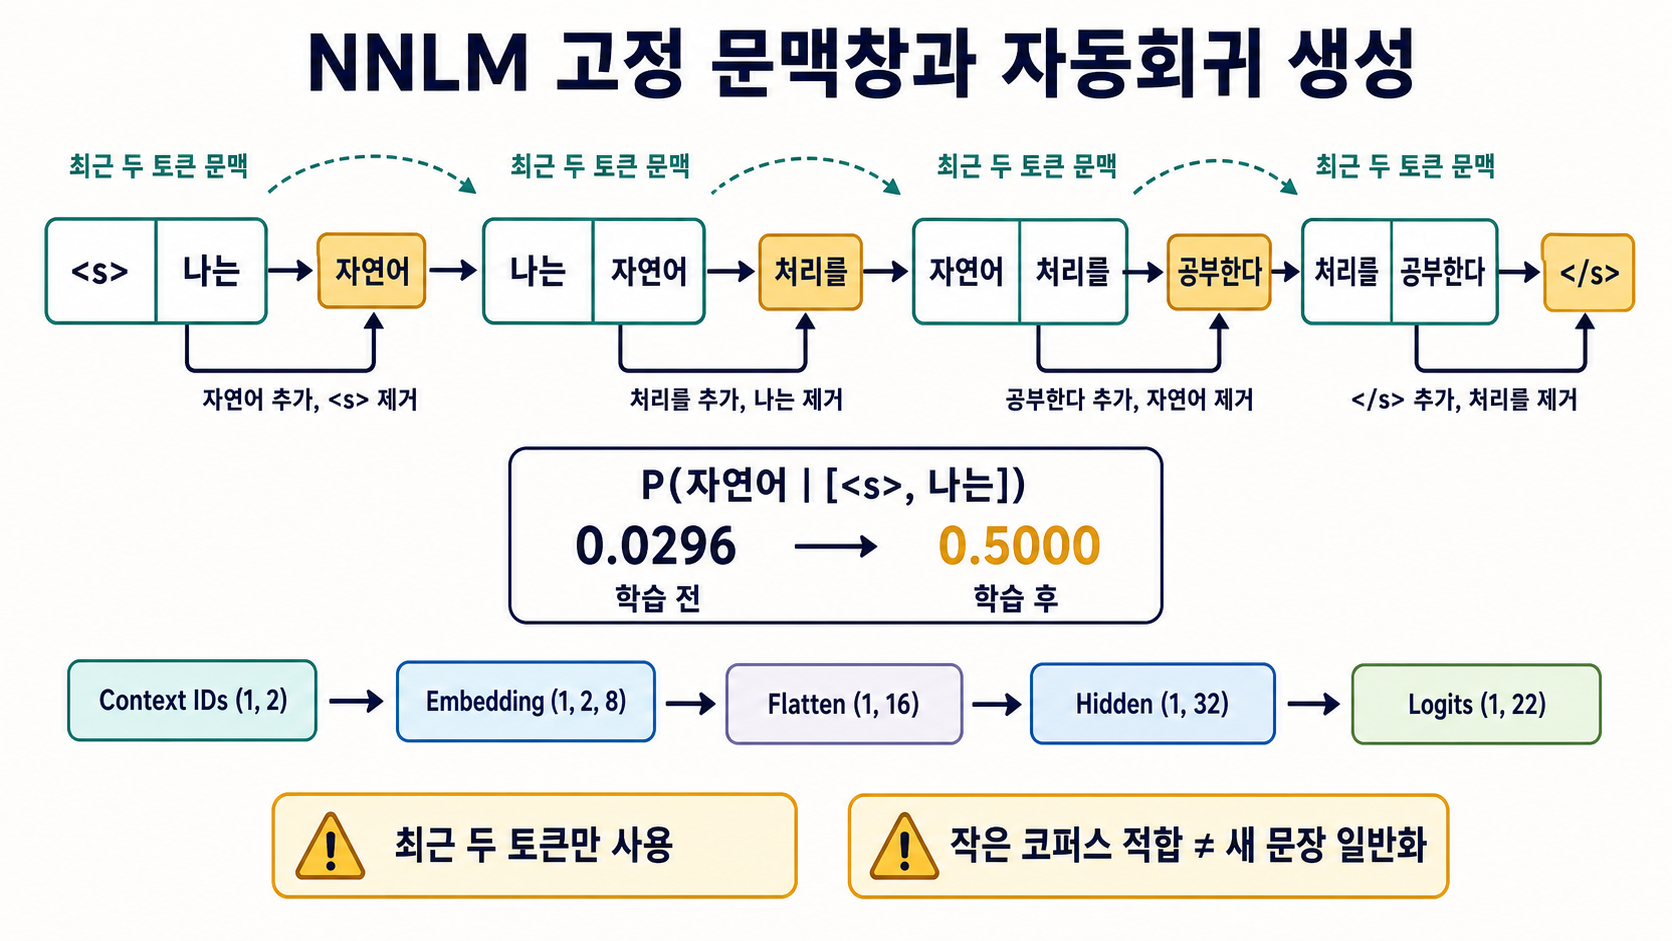
